## 🏨 Hotel Booking Cancellation Prediction using ML Classifiers

### 📌 Business Problem

Hotels frequently experience booking cancellations, which can lead to revenue loss, inefficient room allocation, and increased operational costs. Being able to predict whether a booking is likely to be canceled enables hotels to take proactive measures, such as optimizing room inventory, offering promotional incentives, or adjusting cancellation policies.

The objective of this project is to build a machine learning model that predicts whether a hotel booking will be **canceled** or **not canceled** based on customer information, booking details, and reservation history. Multiple classification models will be trained and compared to identify the most effective approach for predicting booking cancellations.

### 📌 Project Objectives

- Analyze the factors influencing hotel booking cancellations.
- Perform exploratory data analysis (EDA) to identify patterns and trends.
- Clean and preprocess the dataset for machine learning.
- Train and compare **Logistic Regression**, **Decision Tree** and **Random Forest** classifiers.
- Evaluate model performance using classification metrics.
- Identify the most important features influencing booking cancellations.
- Provide business insights and recommendations to help hotels reduce cancellation rates.

In [1]:
# Import the required libraries
import kagglehub
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib
import warnings
warnings.filterwarnings('ignore')

### Data Loading and Understanding

In [2]:
# Load the dataset
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")
df = pd.read_csv(os.path.join(path, "hotel_bookings.csv"))
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [3]:
# Check for statistical values
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [4]:
# Check for data information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

### Data Cleaning

In [5]:
# Check for missing values
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [6]:
# Deleting the 4 rows where children column is null as it is very less
df = df.dropna(subset=['children'])

In [7]:
# Replace the missing values of country and agent with its mode
country_mode = df['country'].mode()[0]
agent_mode = df['agent'].mode()[0]
df['country'] = df['country'].fillna(country_mode)
df['agent'] = df['agent'].fillna(agent_mode)

In [8]:
# Delete the company column as majority of its value is missing
df = df.drop(columns=['company'])

In [9]:
# Remove the duplicate data
df = df.drop_duplicates(keep='last')

### Exploratory Data Analysis

In [10]:
# Segregate the numerical and categorical columns for specific type of visualization
cont_numerical_cols = ['adr', 'lead_time', 'previous_bookings_not_canceled', 'days_in_waiting_list']
discrete_numerical_cols = ['adults', 'children', 'babies', 'previous_cancellations', 'booking_changes', 
                           'total_of_special_requests', 'required_car_parking_spaces', 'stays_in_weekend_nights', 
                           'stays_in_week_nights']
categorical_cols =['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 
                   'reserved_room_type', 'deposit_type', 'agent', 'customer_type']
date_cols = ['arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month']
data_leak_cols = ['assigned_room_type', 'reservation_status', 'reservation_status_date']
target = ['is_canceled']

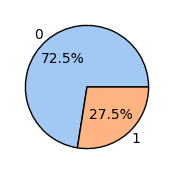

In [11]:
# Check if the output column is equally distributed
plt.figure(figsize=(2,2))
df['is_canceled'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'),
                                       wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.show()

The output data is not equally distributed. There is major share of almost 3/4th non cancelled results in the data.

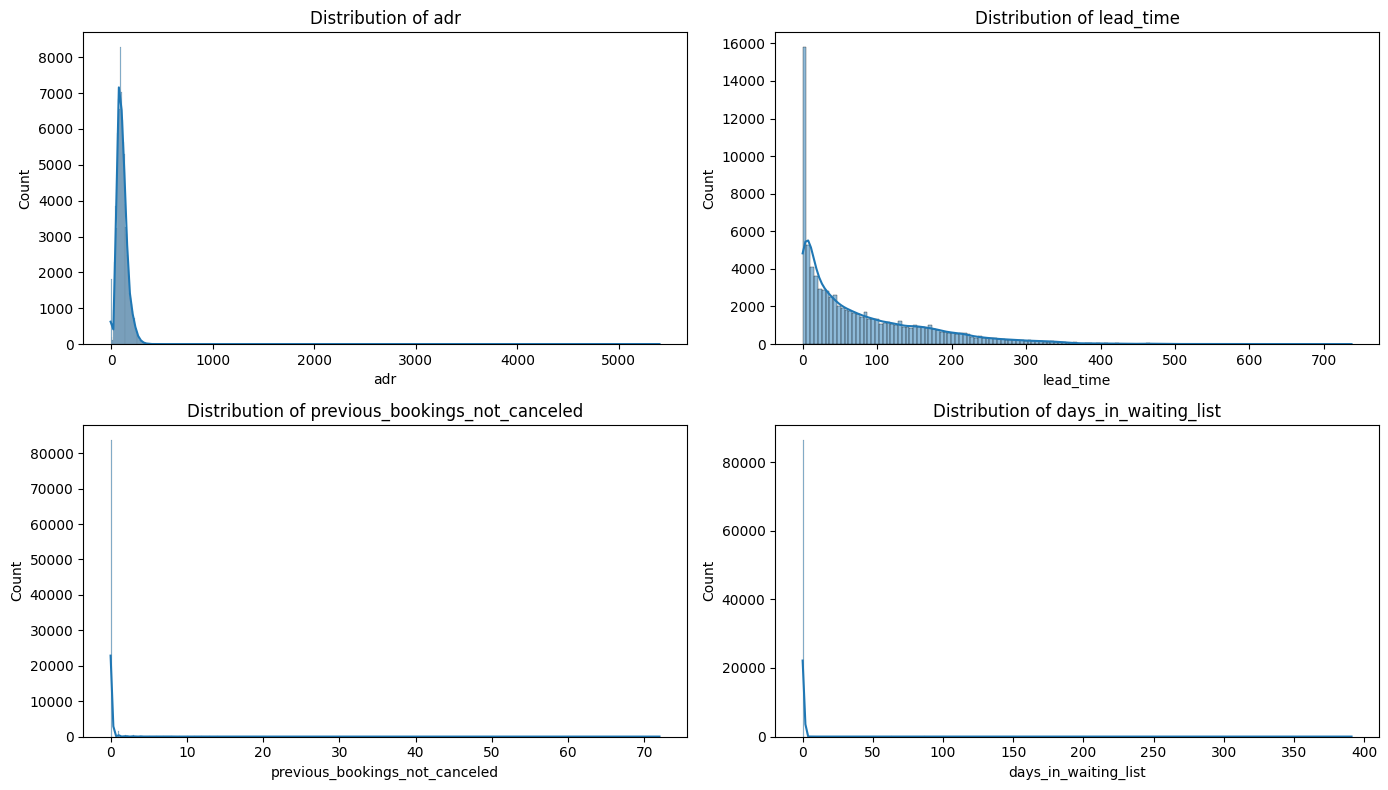

In [12]:
# Visualize the continous numerical columns using Histogram
no_of_rows = int((len(cont_numerical_cols)+1)/2)
fig, axes = plt.subplots(no_of_rows, 2, figsize=(14, 4*no_of_rows))
axes = axes.flatten()
for i, col in enumerate(cont_numerical_cols):
    sns.histplot(data=df, x=col, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')
# Remove unused subplots (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

1. The Average Daily Rate (ADR) is highly right-skewed. Most bookings have moderate room prices, while a few bookings have exceptionally high ADR values, indicating the presence of premium bookings or potential outliers.
2. Most customers book their stay within a relatively short period before arrival. Long lead-time bookings are less common, suggesting that advance reservations are made by a smaller proportion of guests.
3. The distribution of previous non cancelled bookings has a huge spike at 0. It means maximum bookings have been made by the first time customers.
4. The waiting days column also has a huge spike at 0. This shows maximum hotels generally have enough room availability, so most bookings are confirmed without waiting.

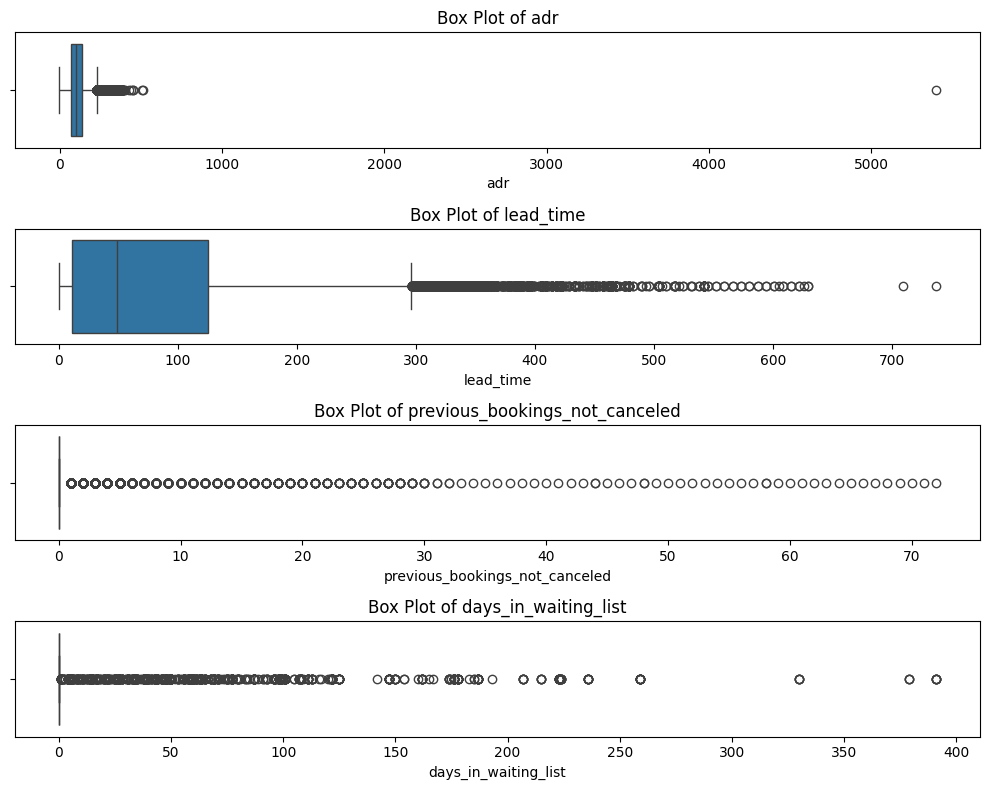

In [13]:
# Detect the outliers using boxplot
no_of_rows = len(cont_numerical_cols)
fig, axes = plt.subplots(no_of_rows, 1, figsize=(10, 2*no_of_rows))
axes = axes.flatten()
for i, col in enumerate(cont_numerical_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Box Plot of {col}')
# Remove unused subplots (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

1. Most guests pay similar room rates, but a few bookings are significantly more expensive. The extreme points needs further investigation.
2. Hotels mainly receive bookings within the first few months before arrival, while very early bookings are relatively rare.
3. Most of the customers have booked for the first time, but there exists a few customers having previous bookings upto 70 times, which is most likely corporate clients or travel agents.
4. There are few outliers of waiting days which needs further investigation.

In [14]:
# Investigate the ADR which is more than 1000
df[df['adr']>1000]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
48515,City Hotel,1,35,2016,March,13,25,0,1,2,...,1,Non Refund,12.0,0,Transient,5400.0,0,0,Canceled,2016-02-19


In [15]:
# Remove the outlier
df = df[df['adr']<=1000]

One record with very high ADR was found. This seems to be a data entry error as there are no supporting feature indicating such high tarrif. Hence, this record has been removed.

In [16]:
# Investigate the lead time which is more than 1 year
df[df['lead_time']>365]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,4,No Deposit,9.0,0,Transient,0.00,0,0,Check-Out,2015-07-01
81,Resort Hotel,1,368,2015,July,27,3,3,7,2,...,0,No Deposit,40.0,0,Contract,55.68,0,0,Canceled,2015-05-19
225,Resort Hotel,0,394,2015,July,28,8,2,5,2,...,0,No Deposit,40.0,0,Contract,89.68,0,0,Check-Out,2015-07-15
245,Resort Hotel,0,366,2015,July,28,9,2,5,2,...,0,No Deposit,40.0,0,Contract,134.73,0,0,Check-Out,2015-07-16
1516,Resort Hotel,0,381,2015,September,36,1,4,10,2,...,0,No Deposit,40.0,0,Contract,82.88,0,0,Check-Out,2015-09-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118961,City Hotel,0,457,2017,August,34,25,0,2,2,...,1,No Deposit,6.0,0,Transient-Party,122.40,0,1,Check-Out,2017-08-27
119102,City Hotel,0,518,2017,August,34,26,2,1,1,...,1,No Deposit,229.0,0,Transient-Party,0.00,0,0,Check-Out,2017-08-29
119107,City Hotel,0,518,2017,August,34,26,2,1,2,...,0,No Deposit,229.0,0,Transient-Party,112.67,0,1,Check-Out,2017-08-29
119111,City Hotel,0,518,2017,August,34,26,2,1,2,...,0,No Deposit,229.0,0,Transient-Party,112.67,0,1,Check-Out,2017-08-29


The above outlier records are kept as the associated booking details such as ADR, customer type, and reservation status didn't indicate data-entry errors. Long lead times may actually correlate with cancellation behavior, and removing these observations could discard useful information.

In [17]:
# Investigate the records with waiting more than 200
df[df['days_in_waiting_list']>200]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
49261,City Hotel,0,268,2016,April,15,8,2,3,2,...,0,No Deposit,21.0,224,Transient-Party,78.00,0,0,Check-Out,2016-04-13
49271,City Hotel,0,268,2016,April,15,8,2,3,2,...,1,No Deposit,21.0,224,Transient-Party,78.00,0,0,Check-Out,2016-04-13
49272,City Hotel,1,268,2016,April,15,8,2,3,2,...,0,No Deposit,21.0,224,Transient-Party,78.00,0,0,Canceled,2016-03-29
49273,City Hotel,0,268,2016,April,15,8,2,3,2,...,0,No Deposit,21.0,224,Transient-Party,78.00,0,0,Check-Out,2016-04-13
49274,City Hotel,0,268,2016,April,15,8,2,3,2,...,0,No Deposit,21.0,224,Transient,78.00,0,0,Check-Out,2016-04-13
50582,City Hotel,0,288,2016,May,19,5,0,3,2,...,0,No Deposit,1.0,259,Transient-Party,62.50,0,1,Check-Out,2016-05-08
50593,City Hotel,0,288,2016,May,19,5,0,3,2,...,0,No Deposit,1.0,236,Transient-Party,81.67,0,0,Check-Out,2016-05-08
50601,City Hotel,0,288,2016,May,19,5,0,3,3,...,1,No Deposit,1.0,259,Transient-Party,71.00,0,1,Check-Out,2016-05-08
50602,City Hotel,0,288,2016,May,19,5,0,3,2,...,0,No Deposit,1.0,259,Transient-Party,65.00,0,1,Check-Out,2016-05-08
50613,City Hotel,0,288,2016,May,19,5,0,3,2,...,0,No Deposit,1.0,259,Transient-Party,62.50,0,0,Check-Out,2016-05-08


Investigation shows these are primarily City Hotel bookings, often associated with Transient-Party customers, suggesting high-demand group reservations.
These records appear to be valid business cases rather than data quality issues and are therefore retained for modeling.

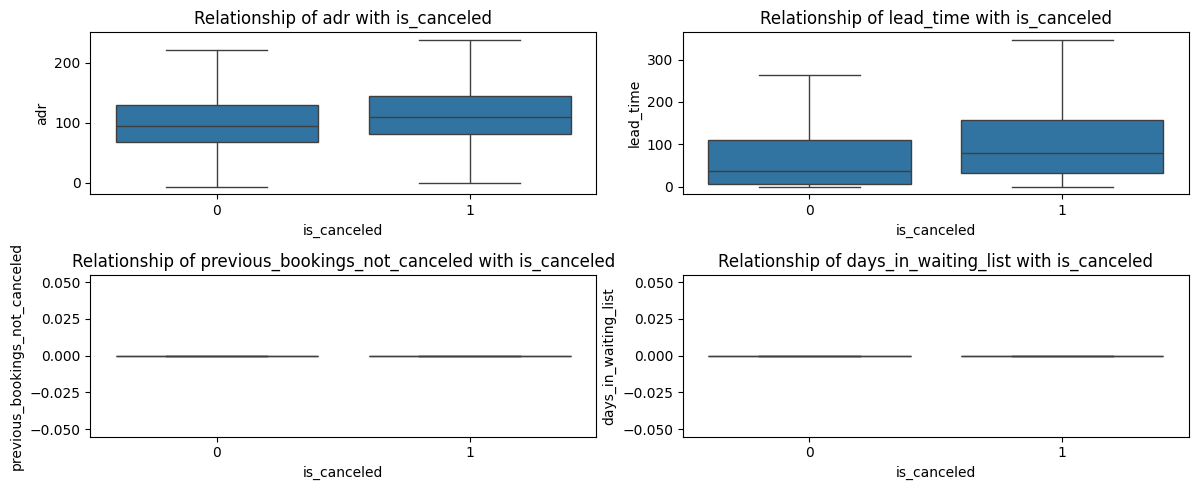

In [18]:
# Visualize the relationship of the numerical colums with the target
no_of_rows = (len(cont_numerical_cols)+1)//2
fig, axes = plt.subplots(no_of_rows, 2, figsize=(12, 5))
axes = axes.flatten()
for i, col in enumerate(cont_numerical_cols):
    sns.boxplot(data=df[cont_numerical_cols+target], x=target[0], y=col, showfliers=False, ax=axes[i])
    axes[i].set_title(f'Relationship of {col} with is_canceled')
# Remove unused subplots (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

1. Customers who canceled their bookings generally had slightly higher room rates. However, the large overlap between the two groups indicates that ADR alone is not a strong predictor of booking cancellation.
2. Customers who booked well in advance were considerably more likely to cancel their reservations. Lead time appears to be a strong predictor of booking cancellation.
3. Both previous non cancelled booking and waiting list days are extremely zero-dominated. So, box plots cannot effectively visualize them.

In [19]:
# Compare the relation between waiting list days and the target
df['has_waiting'] = df['days_in_waiting_list'] > 0
pd.crosstab(df['has_waiting'], df['is_canceled'], normalize='index')*100

is_canceled,0,1
has_waiting,,
False,72.573523,27.426477
True,65.813953,34.186047


Around 34% of the customers who were in waiting list has cancelled their booking whereas only 27% of customers having confirmed bookings have cancelled. It shows a strong relationship with the target and can be a good predictor for the model.

In [20]:
# Compare the relation between previous booking and the target
df['repeat_customer'] = df['previous_bookings_not_canceled'] > 0
pd.crosstab(df['repeat_customer'], df['is_canceled'], normalize='index')*100

is_canceled,0,1
repeat_customer,,
False,71.555375,28.444625
True,95.007052,4.992948


Around 28% of the new customers have cancelled their bookings, whereas only about 5% of the existing customers have cancelled their booking. It shows that this freature can be a good predictor for the model.

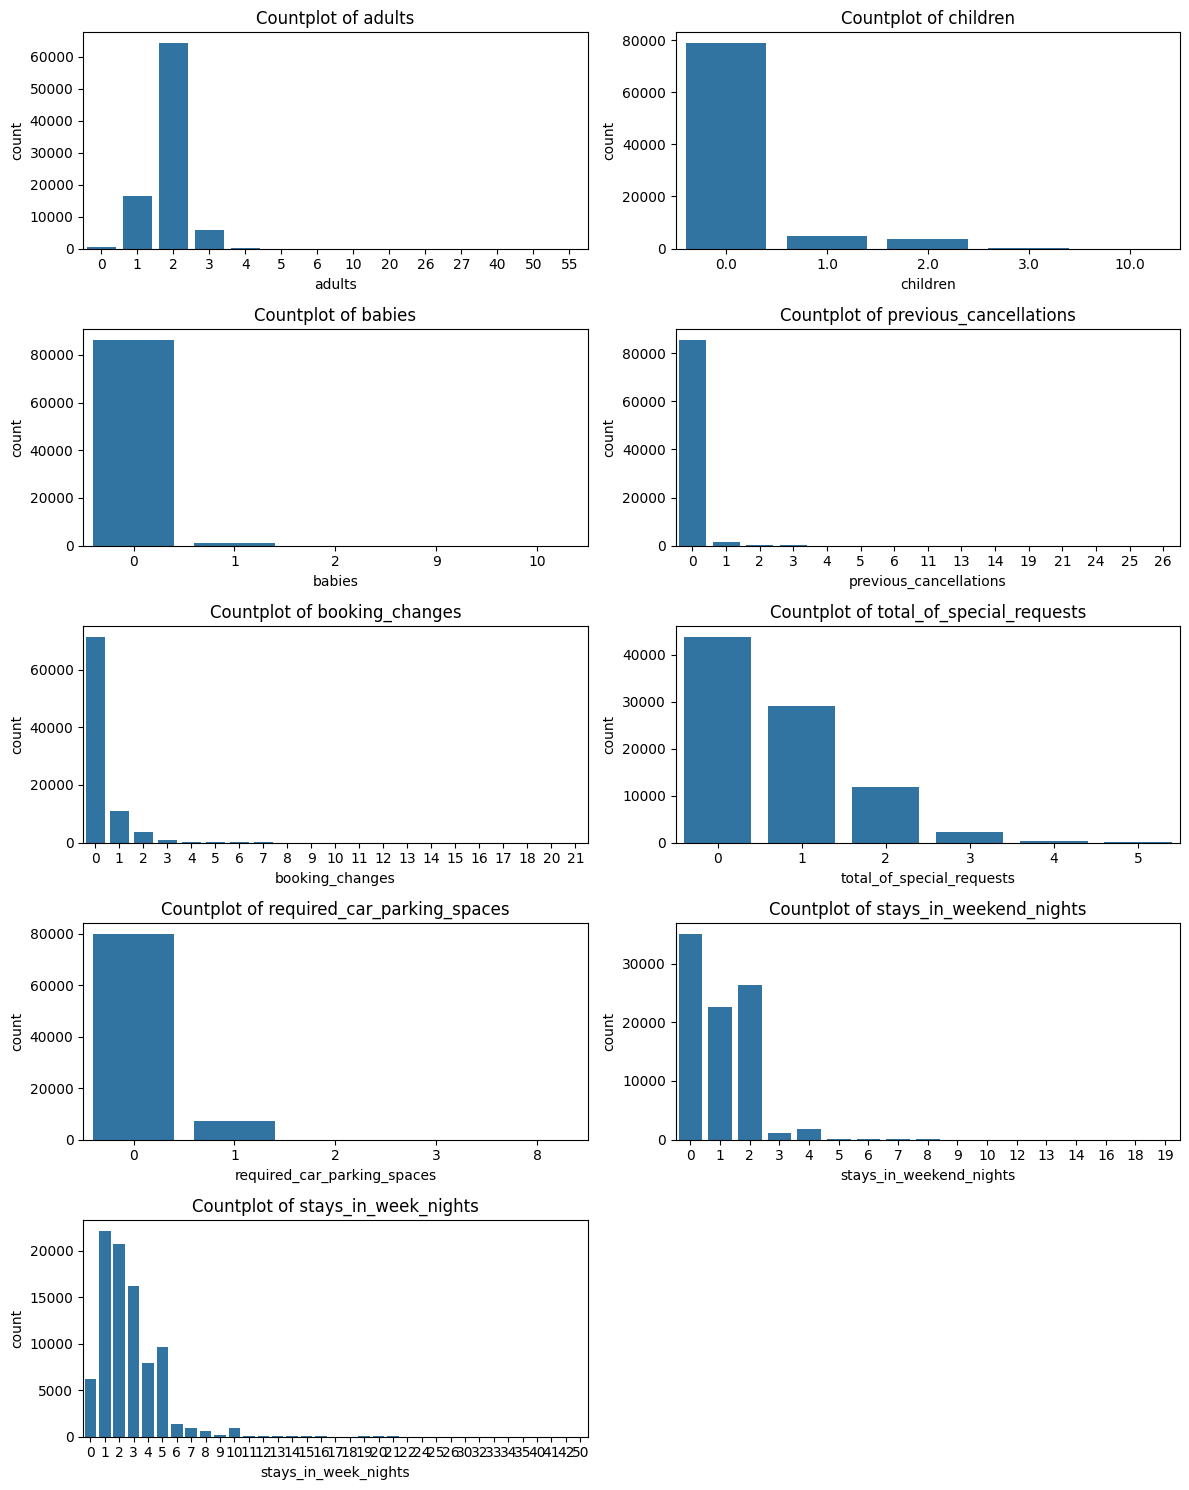

In [21]:
# Visualize the discrete numerical columns using Countplot
no_of_rows = (len(discrete_numerical_cols)+1)//2
fig, axes = plt.subplots(no_of_rows, 2, figsize=(12, 15))
axes = axes.flatten()
for i, col in enumerate(discrete_numerical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Countplot of {col}')
# Remove unused subplots (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

#### Business Insights
##### Adults

1. Most bookings are made for 2 adults, followed by 1 and 3 adults, indicating couples and small groups are the primary customers.
2. Very few bookings involve more than 10 adults, which may represent group or corporate bookings and require further investigation.

##### Children

1. The majority of bookings are made without children.
2. A very small number of bookings have an unusually high number of children (9–10), which should be investigated as potential data anomalies.

##### Babies

1. Almost all bookings have no babies, with very few bookings including one baby.
2. Bookings with more than one baby are extremely rare.

##### Previous Cancellations

1. Most customers have no history of previous cancellations.
2. Only a few customers have multiple past cancellations, which may indicate frequent travellers or corporate/agency bookings.

##### Booking Changes

1. The majority of bookings are not modified after reservation.
2. Only a small number of bookings undergo multiple changes, and records with a high number of modifications should be investigated.

##### Total Special Requests

1. Most customers make 0 or 1 special request.
2. The number of bookings decreases as the number of special requests increases.

##### Required Car Parking Spaces

1. Most bookings do not require parking spaces.
2. Requests for multiple parking spaces are very uncommon and may correspond to group bookings.

##### Stays in Weekend Nights

1. Most bookings include 0–2 weekend nights, indicating short weekend stays are more common.
2. Long weekend stays are relatively rare.

##### Stays in Week Nights

1. Most guests stay for 1–4 week nights, suggesting that short-duration stays are the most common.
2. Long stays extending beyond one week are uncommon.

In [22]:
# Investigate the data with large number of childrens
df.loc[((df['babies']>=9) | (df['children']==10)), ['adults', 'children', 'babies']]

,adults,children,babies
328,2,10.0,0
46619,2,0.0,10
78656,1,0.0,9


The above data looks erronous as it is impossible to have a family with 2 adults and 9 to 10 babies. So, those records will be removed.
The record with 10 children and 2 adults can be possible for a school outing of 10 childrens with 2 teachers. Hence, this record will be kept.

In [23]:
# Remove the records with 9 or 10 babies
df = df[df['babies']<9]

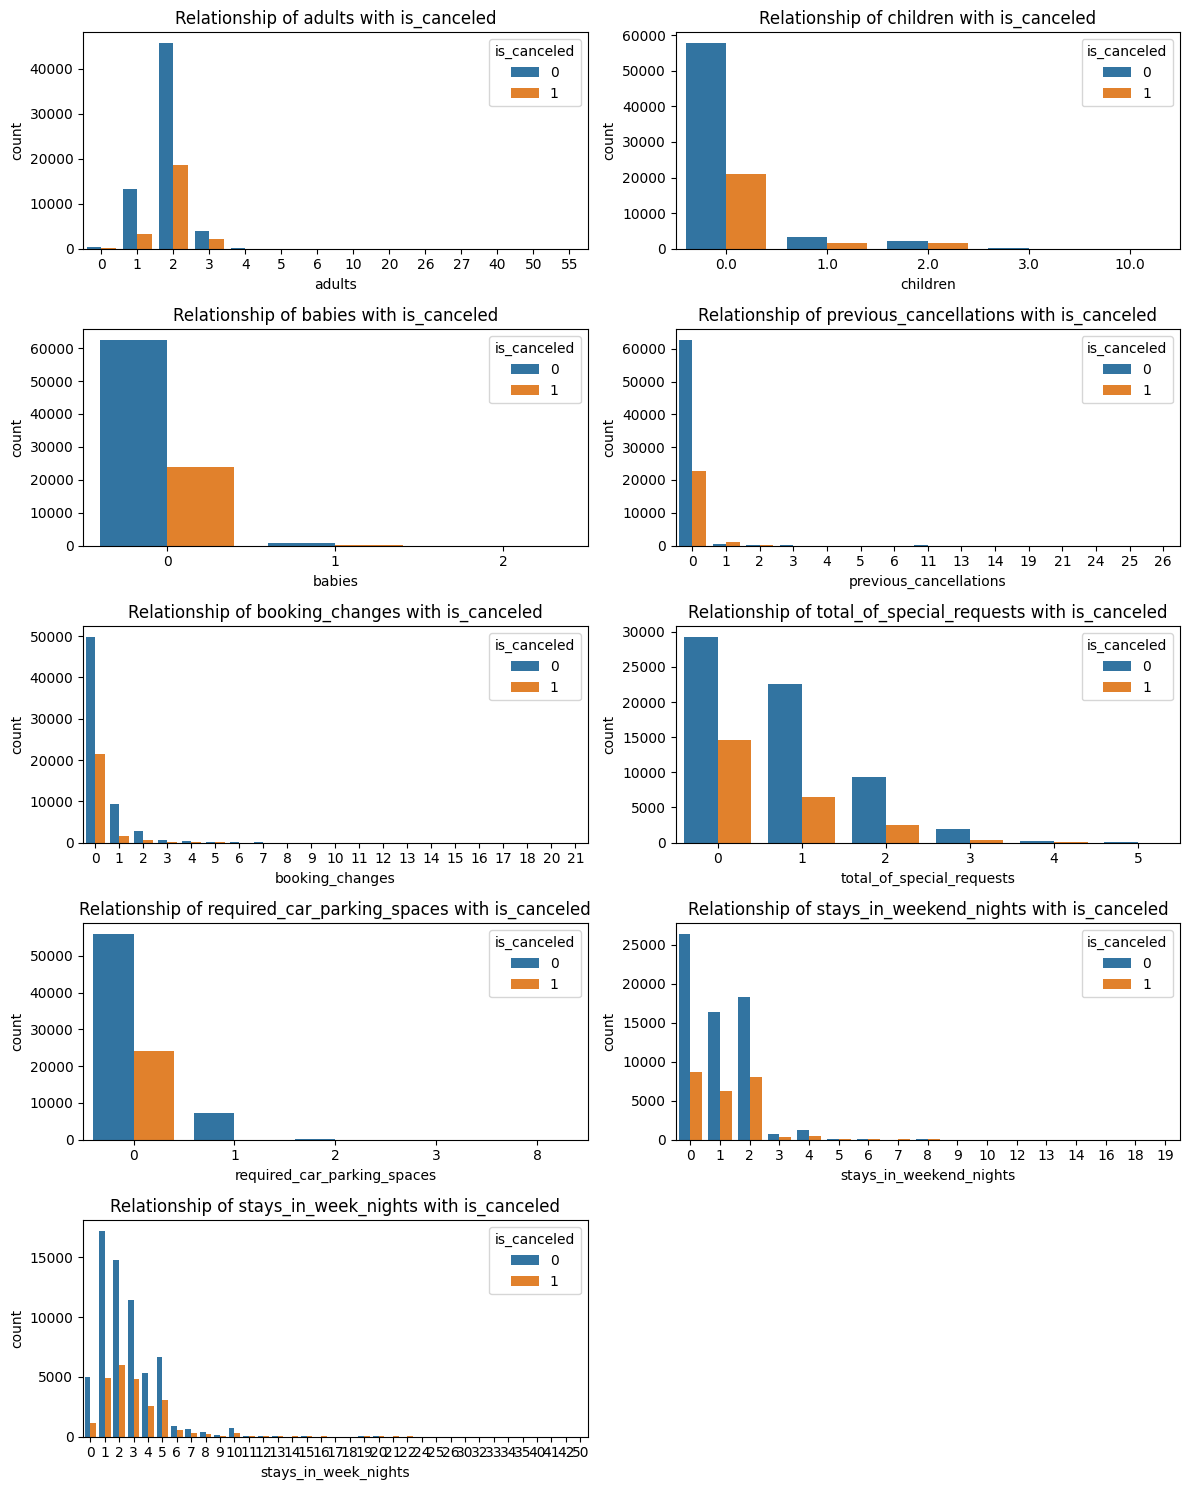

In [24]:
# Visualize the relationship of the discrete numerical colums with the target
no_of_rows = (len(discrete_numerical_cols)+1)//2
fig, axes = plt.subplots(no_of_rows, 2, figsize=(12, 15))
axes = axes.flatten()
for i, col in enumerate(discrete_numerical_cols):
    sns.countplot(data=df[discrete_numerical_cols+target], x=col, hue='is_canceled', ax=axes[i])
    axes[i].set_title(f'Relationship of {col} with is_canceled')
# Remove unused subplots (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Significant insights can't be developed from the above countplots. So, the cancellation rate for each category needs to be calculated using crosstab function.

In [25]:
# Visualize the relation between the discrete numerical columns with the cancellation rate
df['adults_group'] = df['adults'].apply(lambda x: '5+' if x>=5 else str(x))
df['has_previous_cancellations'] = df['previous_cancellations'] > 0
df['booking_changes_group'] = df['booking_changes'].apply(lambda x: '7+' if x>=7 else str(x))
df['required_car_parking'] = df['required_car_parking_spaces'] > 0
df['weekend_stay_group'] = df['stays_in_weekend_nights'].apply(lambda x: '5+' if x>=5 else str(x))
df['weekdays_stay_group'] = df['stays_in_week_nights'].apply(lambda x: '9+' if x>=9 else str(x))
discrete_numerical_features = ['adults_group', 'has_previous_cancellations', 'children', 'babies', 
                               'booking_changes_group', 'total_of_special_requests', 'required_car_parking',
                               'weekend_stay_group', 'weekdays_stay_group']
for col in discrete_numerical_features:
    display(pd.crosstab(df[col], df['is_canceled'], normalize='index') * 100)

is_canceled,0,1
adults_group,,
0,74.805195,25.194805
1,80.533819,19.466181
2,71.067895,28.932105
3,65.840917,34.159083
4,76.666667,23.333333
5+,0.000000,100.000000


is_canceled,0,1
has_previous_cancellations,,
False,73.300886,26.699114
True,32.106825,67.893175


is_canceled,0,1
children,,
0.0,73.374009,26.625991
1.0,68.796592,31.203408
2.0,58.168661,41.831339
3.0,78.666667,21.333333
10.0,0.000000,100.000000


is_canceled,0,1
babies,,
0,72.409485,27.590515
1,81.605351,18.394649
2,86.666667,13.333333


is_canceled,0,1
booking_changes_group,,
0,69.826766,30.173234
1,86.144247,13.855753
2,79.931585,20.068415
3,85.028571,14.971429
4,82.303371,17.696629
5,82.758621,17.241379
6,71.186441,28.813559
7+,87.209302,12.790698


is_canceled,0,1
total_of_special_requests,,
0,66.786707,33.213293
1,77.592388,22.407612
2,78.709350,21.290650
3,82.858377,17.141623
4,89.375000,10.625000
5,94.444444,5.555556


is_canceled,0,1
required_car_parking,,
False,69.994628,30.005372
True,100.000000,0.000000


is_canceled,0,1
weekend_stay_group,,
0,75.291773,24.708227
1,72.574734,27.425266
2,69.433191,30.566809
3,66.434783,33.565217
4,69.896194,30.103806
5+,49.310345,50.689655


is_canceled,0,1
weekdays_stay_group,,
0,81.439455,18.560545
1,77.737193,22.262807
2,71.234991,28.765009
3,70.130429,29.869571
4,67.526035,32.473965
5,68.722832,31.277168
6,62.291516,37.708484
7,69.389866,30.610134
8,67.536705,32.463295


#### Insights and Observations
1. Adults: Bookings made by a single adult have the lowest cancellation rate, while the cancellation rate generally increases with the number of adults. This feature will be retained for model training.
2. Previous Cancellations: Customers with previous cancellations are significantly more likely to cancel again, making this a strong predictor of booking cancellation.
3. Children: The number of children does not show a consistent relationship with cancellation, although bookings with two children have a relatively higher cancellation rate. This feature alone is not a strong predictor for cancellation.
4. Babies: Customers travelling with babies tend to have lower cancellation rates. This feature will be retained for model training.
5. Booking Changes: Bookings with no modifications have the highest cancellation rate, while customers making one or more booking changes are less likely to cancel. This appears to be a moderate predictor.
6. Special Requests: Customers with no special requests have the highest cancellation rate, and the cancellation rate consistently decreases as the number of special requests increases. This is a strong predictor.
7. Car Parking Requirement: Customers requesting car parking rarely cancel their bookings, suggesting that this feature is a useful predictor. However, the result should be interpreted with caution due to the smaller number of such bookings.
8. Length of Stay: Cancellation rates generally increase with longer weekday and weekend stays, indicating that both features may contribute to predicting booking cancellations.

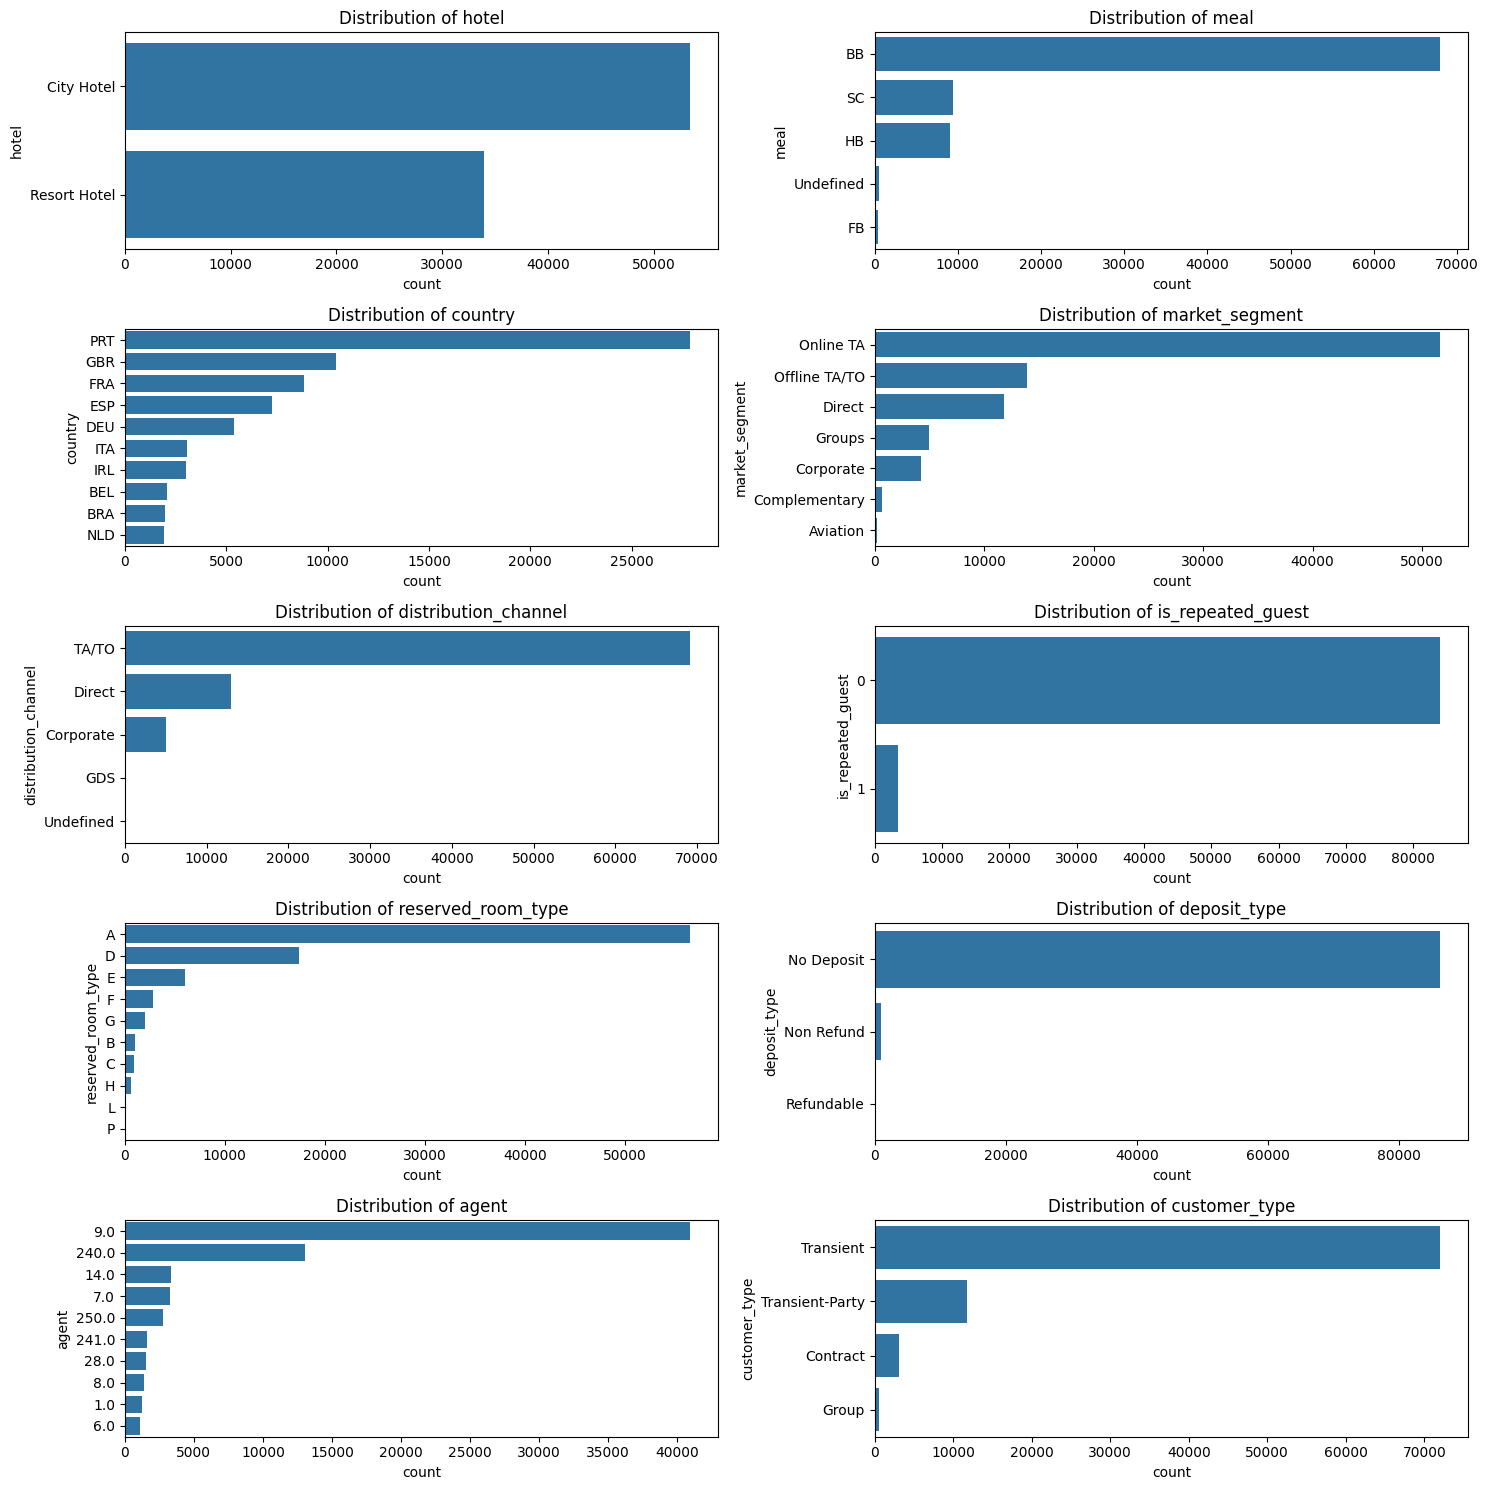

In [26]:
# Visualize the categorical columns using Countplot
no_of_rows = (len(categorical_cols)+1)//2
fig, axes = plt.subplots(no_of_rows, 2, figsize=(15, 15))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    if col in ['country', 'agent']:
        order = df[col].value_counts().head(10).index
    else:
        order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
# Remove unused subplots (if any)
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

#### Business Insights
1. The majority of the bookings are for City Hotels, while Resort Hotels account for a smaller share of bookings.
2. BB (Bed & Breakfast) is the most preferred meal type, followed by SC (Self Catering) and HB (Half Board). A small number of bookings have an Undefined meal type, which should be handled during preprocessing.
3. Most bookings are made by customers from Portugal, followed by Great Britain, France, and other countries.
4. The Online Travel Agency (Online TA) segment contributes the highest number of bookings, followed by Offline Travel Agency/Tour Operator and Direct bookings.
5. The TA/TO (Travel Agent/Tour Operator) distribution channel is used the most, followed by the Direct distribution channel.
6. Most bookings are made by new customers, while repeat guests account for only a small proportion of the bookings.
7. Room Type A is the most frequently reserved room type, followed by Room Types D and E.
8. The vast majority of bookings are made without any deposit, while Non-Refund and Refundable deposits are comparatively rare.
9. Agent ID 9 handles the highest number of bookings, followed by Agent ID 240. Most other agents contribute relatively few bookings.
10. Transient customers (individual travelers) account for the majority of bookings, followed by Transient-Party customers (individual travelers booking together).

In [27]:
# Visualize the relation between the categorical columns with the cancellation rate
top_10_countries = df['country'].value_counts().head(10).index
top_10_agents = df['agent'].value_counts().head(10).index
for col in categorical_cols:
    if col == 'country':
        temp = df[df['country'].isin(top_10_countries)]
    elif col == 'agent':
        temp = df[df['agent'].isin(top_10_agents)]
    else: 
        temp = df
    display(pd.crosstab(temp[col], temp['is_canceled'], normalize='index')*100)

is_canceled,0,1
hotel,,
City Hotel,69.965180,30.034820
Resort Hotel,76.505421,23.494579


is_canceled,0,1
meal,,
BB,73.448423,26.551577
FB,72.500000,27.500000
HB,73.029502,26.970498
SC,64.697817,35.302183
Undefined,83.265306,16.734694


is_canceled,0,1
country,,
BEL,80.249880,19.750120
BRA,63.558897,36.441103
DEU,80.452942,19.547058
ESP,74.320783,25.679217
FRA,80.389272,19.610728
GBR,80.970185,19.029815
IRL,77.851459,22.148541
ITA,64.938030,35.061970
NLD,81.684982,18.315018


is_canceled,0,1
market_segment,,
Aviation,80.176211,19.823789
Complementary,87.464387,12.535613
Corporate,87.860033,12.139967
Direct,85.284394,14.715606
Groups,72.975709,27.024291
Offline TA/TO,85.156644,14.843356
Online TA,64.650262,35.349738


is_canceled,0,1
distribution_channel,,
Corporate,87.218935,12.781065
Direct,85.169492,14.830508
GDS,80.110497,19.889503
TA/TO,69.029365,30.970635
Undefined,100.000000,0.000000


is_canceled,0,1
is_repeated_guest,,
0,71.698810,28.301190
1,92.357247,7.642753


is_canceled,0,1
reserved_room_type,,
A,74.021264,25.978736
B,68.442211,31.557789
C,67.650273,32.349727
D,69.901127,30.098873
E,72.730279,27.269721
F,69.844082,30.155918
G,64.083821,35.916179
H,59.228188,40.771812
L,66.666667,33.333333


is_canceled,0,1
deposit_type,,
No Deposit,73.310678,26.689322
Non Refund,5.303761,94.696239
Refundable,75.700935,24.299065


is_canceled,0,1
agent,,
1.0,62.824675,37.175325
6.0,84.139785,15.860215
7.0,86.787879,13.212121
8.0,72.161967,27.838033
9.0,68.046325,31.953675
14.0,82.616487,17.383513
28.0,94.207723,5.792277
240.0,62.045140,37.954860
241.0,86.739659,13.260341


is_canceled,0,1
customer_type,,
Contract,83.689073,16.310927
Group,90.073529,9.926471
Transient,69.888140,30.111860
Transient-Party,84.778897,15.221103


##### Hotel
City Hotels have a higher cancellation rate (30.03%) compared to Resort Hotels (23.49%). The hotel feature appears to be a useful predictor of booking cancellation.

##### Meal
Customers choosing SC (Self Catering) have the highest cancellation rate (35.30%) among the common meal plans.
Customers with Undefined meal type have the lowest cancellation rate (16.73%), though this category contains relatively few observations. Meal shows a moderate relationship with cancellation.

##### Country
Cancellation rates vary considerably across countries. Since many countries have very few bookings, conclusions based on individual countries may not be reliable.

##### Market Segment
Online TA bookings have the highest cancellation rate (35.35%). Corporate, Direct, and Offline TA/TO bookings have much lower cancellation rates (around 12–15%). Market Segment appears to be a strong predictor of cancellation.

##### Distribution Channel
Bookings through the TA/TO channel have the highest cancellation rate (30.97%). Corporate and Direct channels have considerably lower cancellation rates. This feature also appears to be a strong predictor.

##### Repeated Guest
Repeat guests have a cancellation rate of only 7.64%, compared to 28.30% for new guests. This is one of the strongest predictors in the dataset.

##### Reserved Room Type
Cancellation rates vary across room types. Room Types G and H show relatively higher cancellation rates, while Room Type A has a comparatively lower rate. This feature can be retained for model training.

##### Deposit Type
Non-Refund bookings have an extremely high cancellation rate (94.70%). No Deposit and Refundable bookings have much lower cancellation rates. Deposit Type is one of the strongest predictors of cancellation.

##### Agent
Cancellation rates vary substantially across different agents. Since there are over 300 agents, many have very few bookings, making individual percentages unreliable. However looking at the top 10 agents, this feature can be kept for model training.

##### Customer Type
Transient customers have the highest cancellation rate (30.11%). Contract, Group, and Transient-Party customers have much lower cancellation rates. Customer Type appears to be a useful predictor.

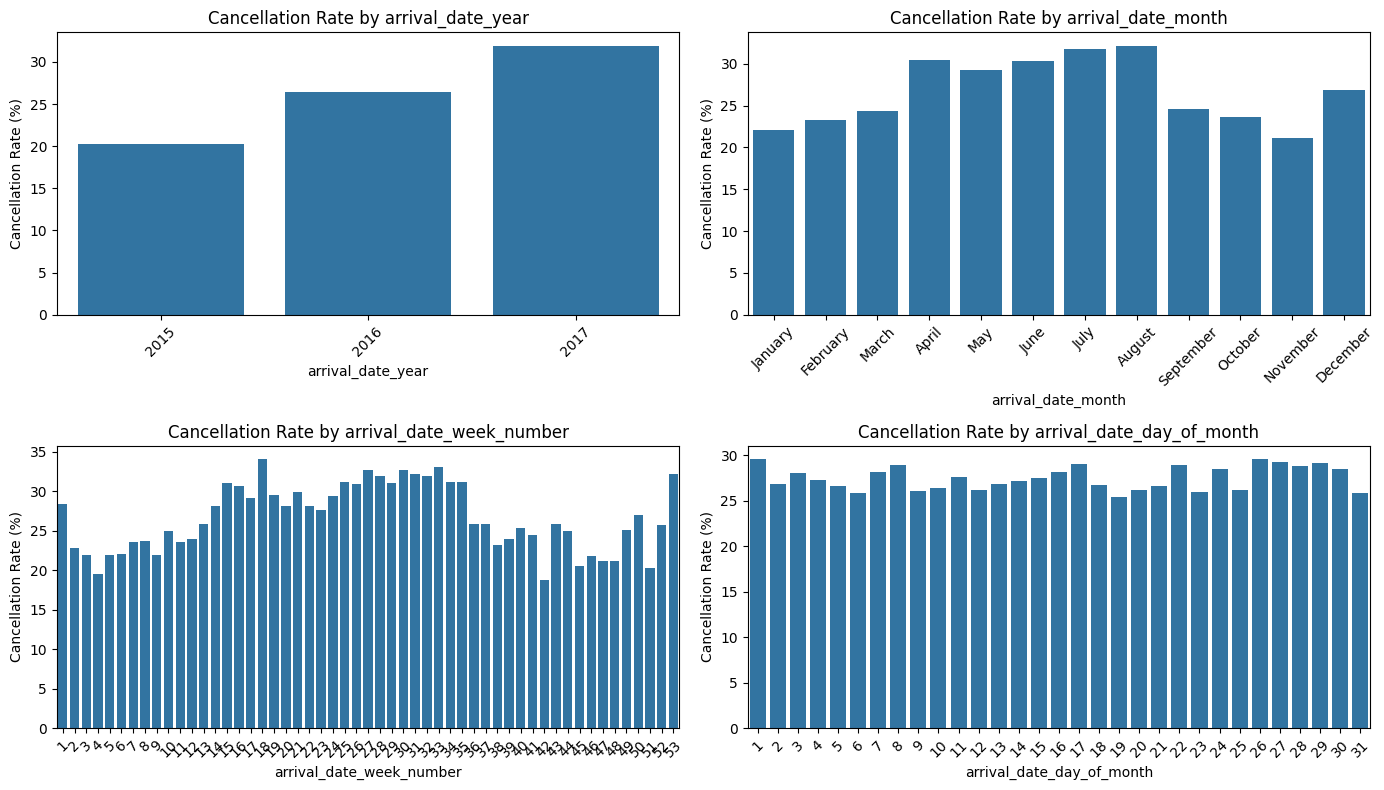

In [28]:
# Visualize cancellation rate for date features
no_of_rows = (len(date_cols) + 1)//2
fig, axes = plt.subplots(no_of_rows, 2, figsize=(14, 4 * no_of_rows))
axes = axes.flatten()
for i, col in enumerate(date_cols):
    cancel_rate = (pd.crosstab(df[col], df['is_canceled'], normalize='index')*100)[1]
    if col == 'arrival_date_month':
        month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 
                       'October', 'November', 'December']
        cancel_rate = cancel_rate.reindex(month_order)
    sns.barplot(x=cancel_rate.index, y=cancel_rate.values, ax=axes[i])
    axes[i].set_title(f'Cancellation Rate by {col}')
    axes[i].set_ylabel('Cancellation Rate (%)')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)
# Remove unused subplot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

1. Cancellation rate increases from around 20% in 2015 → around 26% in 2016 → around 32% in 2017. This indicates a strong time trend in cancellations. This feature can be used for modeling.
2. Cancellation rates are relatively high around April–August, with August being the highest and are lower around January, November and October. This suggests seasonality in cancellations. This feature can be used.
3. There is condiderable fluctuations in the cancellation rates by the week numbers. This indicates that some parts of the year can have more cancellation than others. This feature can be kept for model training.
4. The cancellation rate for the days of month is mostly flat. No conclusions can be drawn from this feature. This feature can be dropped.

In [29]:
# Keep the useful features for model training
features_to_keep = ['lead_time', 'previous_bookings_not_canceled', 'days_in_waiting_list',
                    'adults', 'previous_cancellations', 'babies', 'booking_changes', 
                    'required_car_parking_spaces', 'stays_in_weekend_nights', 'stays_in_week_nights', 
                    'total_of_special_requests', 'hotel', 'meal', 'country', 'market_segment', 
                    'distribution_channel', 'is_repeated_guest', 'reserved_room_type', 'deposit_type', 
                    'agent', 'customer_type', 'arrival_date_year', 'arrival_date_month', 
                    'arrival_date_week_number']

In [30]:
# Final dataset for the model training
df = df[features_to_keep+target]
df.head()

,lead_time,previous_bookings_not_canceled,days_in_waiting_list,adults,previous_cancellations,babies,booking_changes,required_car_parking_spaces,stays_in_weekend_nights,stays_in_week_nights,...,distribution_channel,is_repeated_guest,reserved_room_type,deposit_type,agent,customer_type,arrival_date_year,arrival_date_month,arrival_date_week_number,is_canceled
0,342,0,0,2,0,0,3,0,0,0,...,Direct,0,C,No Deposit,9.0,Transient,2015,July,27,0
1,737,0,0,2,0,0,4,0,0,0,...,Direct,0,C,No Deposit,9.0,Transient,2015,July,27,0
2,7,0,0,1,0,0,0,0,0,1,...,Direct,0,A,No Deposit,9.0,Transient,2015,July,27,0
3,13,0,0,1,0,0,0,0,0,1,...,Corporate,0,A,No Deposit,304.0,Transient,2015,July,27,0
5,14,0,0,2,0,0,0,0,0,2,...,TA/TO,0,A,No Deposit,240.0,Transient,2015,July,27,0


In [31]:
# Replace the undefined values of meal column with its mode.
mode_meal = df['meal'].mode()[0]
df['meal'] = df['meal'].replace('Undefined', mode_meal)

### Feature Scaling and Encoding

In [32]:
# Onehot Encoding: Create new columns for all the low cardinality categorical columns
cols_to_encode = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 
                  'deposit_type', 'customer_type', 'arrival_date_year']
if all(col in df.columns for col in cols_to_encode):
    df = pd.get_dummies(data=df, columns=cols_to_encode, dtype=int)
df.head()

,lead_time,previous_bookings_not_canceled,days_in_waiting_list,adults,previous_cancellations,babies,booking_changes,required_car_parking_spaces,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,arrival_date_year_2015,arrival_date_year_2016,arrival_date_year_2017
0,342,0,0,2,0,0,3,0,0,0,...,1,0,0,0,0,1,0,1,0,0
1,737,0,0,2,0,0,4,0,0,0,...,1,0,0,0,0,1,0,1,0,0
2,7,0,0,1,0,0,0,0,0,1,...,1,0,0,0,0,1,0,1,0,0
3,13,0,0,1,0,0,0,0,0,1,...,1,0,0,0,0,1,0,1,0,0
5,14,0,0,2,0,0,0,0,0,2,...,1,0,0,0,0,1,0,1,0,0


In [33]:
# Label Encoding : Change the value of the high cardinality categorical columns
cols = ['country', 'arrival_date_month', 'agent']
label_encoders = {}
for c in cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c])
    label_encoders[c] = le
df.head()

,lead_time,previous_bookings_not_canceled,days_in_waiting_list,adults,previous_cancellations,babies,booking_changes,required_car_parking_spaces,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,arrival_date_year_2015,arrival_date_year_2016,arrival_date_year_2017
0,342,0,0,2,0,0,3,0,0,0,...,1,0,0,0,0,1,0,1,0,0
1,737,0,0,2,0,0,4,0,0,0,...,1,0,0,0,0,1,0,1,0,0
2,7,0,0,1,0,0,0,0,0,1,...,1,0,0,0,0,1,0,1,0,0
3,13,0,0,1,0,0,0,0,0,1,...,1,0,0,0,0,1,0,1,0,0
5,14,0,0,2,0,0,0,0,0,2,...,1,0,0,0,0,1,0,1,0,0


In [35]:
# Feature Scaling: Convert the numerical columns into standard form (mean=0, std=1)
cols_to_scale = ['lead_time', 'previous_bookings_not_canceled', 'days_in_waiting_list', 'adults', 
                 'previous_cancellations', 'babies', 'booking_changes', 'required_car_parking_spaces',
                 'stays_in_weekend_nights', 'stays_in_week_nights', 'total_of_special_requests']
s = StandardScaler()
df[cols_to_scale] = s.fit_transform(df[cols_to_scale])
df.head()

,lead_time,previous_bookings_not_canceled,days_in_waiting_list,adults,previous_cancellations,babies,booking_changes,required_car_parking_spaces,stays_in_weekend_nights,stays_in_week_nights,...,deposit_type_No Deposit,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Contract,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,arrival_date_year_2015,arrival_date_year_2016,arrival_date_year_2017
0,3.045435,-0.106258,-0.074854,0.198025,-0.082405,-0.101907,3.751073,-0.299233,-0.974311,-1.278585,...,1,0,0,0,0,1,0,1,0,0
1,7.635398,-0.106258,-0.074854,0.198025,-0.082405,-0.101907,5.125930,-0.299233,-0.974311,-1.278585,...,1,0,0,0,0,1,0,1,0,0
2,-0.847318,-0.106258,-0.074854,-1.398198,-0.082405,-0.101907,-0.373497,-0.299233,-0.974311,-0.791663,...,1,0,0,0,0,1,0,1,0,0
3,-0.777597,-0.106258,-0.074854,-1.398198,-0.082405,-0.101907,-0.373497,-0.299233,-0.974311,-0.791663,...,1,0,0,0,0,1,0,1,0,0
5,-0.765977,-0.106258,-0.074854,0.198025,-0.082405,-0.101907,-0.373497,-0.299233,-0.974311,-0.304742,...,1,0,0,0,0,1,0,1,0,0


### Model Training and Evaluation

In [36]:
# Separate the input and output columns
x = df.drop(columns=['is_canceled'])
y = df['is_canceled']

In [37]:
# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1, stratify=y)

In [38]:
# Create a dictionary of models
models = {'Logistic Regression': LogisticRegression(max_iter=2000),
          'Decision Tree Classifier': DecisionTreeClassifier(random_state=42),
          'Random Forest Classifier': RandomForestClassifier(n_estimators=100)}

In [39]:
# Train all the models and store their result in a dataframe for evaluation
results = []
for model_name, model_algorithm in models.items():
    model_algorithm.fit(x_train, y_train)
    y_pred = model_algorithm.predict(x_test)
    accuracy = round(accuracy_score(y_test, y_pred),4)*100
    precision = round(precision_score(y_test, y_pred),4)*100
    recall = round(recall_score(y_test, y_pred),4)*100
    f1 = round(f1_score(y_test, y_pred),4)*100
    train_score = round(model_algorithm.score(x_train, y_train)*100, 2)
    test_score = round(model_algorithm.score(x_test, y_test)*100, 2)
    fit = 'Good Fit' if abs(train_score-test_score)<5 else 'Slight Overfit' if abs(train_score-test_score)<10 else 'Overfit'
    results.append({'Model Name': model_name, 'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 
                    'F1 Score': f1, 'Training Score': train_score, 'Test Score': test_score, 'Fit': fit})

In [40]:
# Display the results in a tabular format
df_results = pd.DataFrame(results)
df_results

,Model Name,Accuracy,Precision,Recall,F1 Score,Training Score,Test Score,Fit
0,Logistic Regression,77.73,65.96,39.28,49.24,77.87,77.73,Good Fit
1,Decision Tree Classifier,79.96,63.66,63.22,63.44,99.59,79.96,Overfit
2,Random Forest Classifier,84.39,75.49,63.99,69.27,99.58,84.39,Overfit


Random Forest Classifier performed the best among the three models, achieving the highest Accuracy (84.67%), Precision (75.92%), Recall (64.78%) and F1 Score (69.91%). However, it is overfitting indicating that the model may be too complex and is not generalizing optimally to unseen data. Therefore, we will retune the Random Forest model using GridSearchCV to identify the optimal hyperparameters and reduce overfitting while maintaining or improving the model's test performance.

### Hyperparameter Tuning

In [41]:
# Use Grid Search CV to get the best parameters for Random Forest
param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 15, 20, 25], 'min_samples_split': [5, 10], 
              'min_samples_leaf': [2, 5]}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(x_train, y_train)
print('Best Parameters :', grid_search.best_params_)
print('Best Score :', grid_search.best_score_*100)

Best Parameters : {'max_depth': 25, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best Score : 67.82841114820675


In [42]:
# Train and evaluate the best model
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(x_test)
accuracy_best_rf = round(accuracy_score(y_test, y_pred_best_rf)*100, 2)
precision_best_rf = round(precision_score(y_test, y_pred_best_rf)*100, 2)
recall_best_rf = round(recall_score(y_test, y_pred_best_rf)*100, 2)
f1_best_rf = round(f1_score(y_test, y_pred_best_rf)*100, 2)
train_accuracy_best_rf = best_rf.score(x_train, y_train)*100
test_accuracy_best_rf = best_rf.score(x_test, y_test)*100
fit_best_rf = 'Good Fit' if abs(train_accuracy_best_rf-test_accuracy_best_rf)<5 else 'Slight Overfit' if abs(train_accuracy_best_rf-test_accuracy_best_rf)<10 else 'Overfit'

print("Accuracy :", accuracy_best_rf)
print("Precision:", precision_best_rf)
print("Recall   :", recall_best_rf)
print("F1 Score :", f1_best_rf)
print("Fit :", fit_best_rf)

Accuracy : 84.64
Precision: 78.0
Recall   : 61.47
F1 Score : 68.75
Fit : Slight Overfit


In [43]:
# Store the above results into the results data frame
df_results.loc[len(df_results)] = ['Re-tuned Random Forest Classifier', accuracy_best_rf, precision_best_rf, 
                                   recall_best_rf, f1_best_rf, train_accuracy_best_rf, test_accuracy_best_rf, 
                                   fit_best_rf]
df_results

,Model Name,Accuracy,Precision,Recall,F1 Score,Training Score,Test Score,Fit
0,Logistic Regression,77.73,65.96,39.28,49.24,77.870000,77.730000,Good Fit
1,Decision Tree Classifier,79.96,63.66,63.22,63.44,99.590000,79.960000,Overfit
2,Random Forest Classifier,84.39,75.49,63.99,69.27,99.580000,84.390000,Overfit
3,Re-tuned Random Forest Classifier,84.64,78.00,61.47,68.75,90.251685,84.639158,Slight Overfit


### Model Conclusion
The re-tuned Random Forest Classifier model achieved an accuracy of 84.64%, precision of 78%, recall of 61.47%, and F1 score of 68.75%, while reducing the training-test performance gap from approximately 15% to 5.6%. Although its overall test performance was slightly lower than the original Random Forest, the retuned model provides substantially better generalization and will perform better for unseen data. Hence, it is selected as the final model for deployment.

### Model Deployment

In [44]:
# Saving the best model along with the columns and scaler into a pikle file
joblib.dump(best_rf, 'model_hotel_cancellation_prediction.pkl')
joblib.dump(x.columns.to_list(), 'columns_hotel_cancellation_prediction.pkl')
joblib.dump(s, 'scaler_hotel_cancellation_prediction.pkl')
joblib.dump(label_encoders, 'label_encoders_hotel_cancellation.pkl')

['label_encoders_hotel_cancellation.pkl']